In [1]:
!pip uninstall tensorflow tensorflow-macos tensorflow-metal keras tf-keras -y

In [2]:
# CELL 1: IMPORTS & CONFIGURATION
import os
import time
import logging
import sqlite3
import warnings
import numpy as np
import pandas as pd
import sounddevice as sd
import whisper
from scipy.io.wavfile import write
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Professional Logging Setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger()

# 2. Suppress specific warnings for a clean "Demo Mode"
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# 3. Hardware Check (Apple Silicon Optimization)
import torch
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"🚀 System initialized. AI processing optimized for: {device.upper()}")

🚀 System initialized. AI processing optimized for: MPS


In [3]:
# CELL 2: BACKEND DATABASE (SQLite)

class BankingBackend:
    """
    Manages a robust SQL database for user data.
    Simulates a real banking/hotel backend.
    """
    def __init__(self, db_name="voice_bot_data.db"):
        self.conn = sqlite3.connect(db_name)
        self.cursor = self.conn.cursor()
        self._init_db()

    def _init_db(self):
        # Create users table if it doesn't exist
        self.cursor.execute('''
            CREATE TABLE IF NOT EXISTS users (
                user_id TEXT PRIMARY KEY,
                name TEXT,
                balance REAL,
                account_type TEXT
            )
        ''')
        # Seed Mock Data (Idempotent)
        data = [
            ('101', 'Samantha', 24500.50, 'Platinum'),
            ('102', 'Guest', 0.00, 'Standard')
        ]
        self.cursor.executemany("INSERT OR IGNORE INTO users VALUES (?, ?, ?, ?)", data)
        self.conn.commit()

    def get_user_details(self, user_id):
        """Fetch user details by ID."""
        self.cursor.execute("SELECT * FROM users WHERE user_id=?", (user_id,))
        return self.cursor.fetchone()

    def log_transaction(self, user_id, service_type):
        """Simulate a database write operation (e.g., Booking)."""
        # In a real app, we would insert into a 'transactions' table here
        return f"Confirmed. {service_type} has been successfully logged for User {user_id}."

    def close(self):
        self.conn.close()

# Initialize the backend
backend_system = BankingBackend()
print("✅ Backend: SQL Database Connected & Seeded.")

✅ Backend: SQL Database Connected & Seeded.


In [4]:
# CELL 3: SEMANTIC NLU ENGINE (Hugging Face Transformers)

class SemanticNLU:
    """
    Uses a Transformer model to understand MEANING, not just keywords.
    """
    def __init__(self):
        print("🧠 NLU: Loading Transformer Model (all-MiniLM-L6-v2)...")
        # Downloads a state-of-the-art small model optimized for semantic search
        self.model = SentenceTransformer('all-MiniLM-L6-v2')
        
        # Define 'Anchor Phrases' for each intent
        self.intents = {
            "check_balance": [
                "check my balance", "how much money do I have", 
                "what is in my account", "show my funds", "my savings"
            ],
            "book_hotel": [
                "book a room", "I want to make a reservation", 
                "schedule a stay", "reserve a suite", "hotel booking"
            ],
            "support": [
                "I need help", "customer support", 
                "connect me to an agent", "speak to human"
            ],
            "goodbye": [
                "exit", "stop", "bye", "goodbye", "shut down", "quit"
            ]
        }
        
        # Pre-compute embeddings for speed
        self.intent_embeddings = {}
        for intent, phrases in self.intents.items():
            self.intent_embeddings[intent] = self.model.encode(phrases)
        print("✅ NLU: Engine Ready & Embeddings Cached.")

    def predict_intent(self, text):
        """
        Encodes user text and finds the semantically closest intent.
        """
        user_embedding = self.model.encode(text)
        
        best_intent = "unknown"
        highest_score = 0.0
        
        # Compare user text against all intent groups
        for intent, embeddings in self.intent_embeddings.items():
            # Calculate Cosine Similarity
            scores = util.cos_sim(user_embedding, embeddings)
            max_score_for_intent = float(torch.max(scores))
            
            if max_score_for_intent > highest_score:
                highest_score = max_score_for_intent
                best_intent = intent
        
        # Confidence Threshold (Advanced Safety Feature)
        if highest_score < 0.35: 
            return "unknown", highest_score
            
        return best_intent, highest_score

# Initialize NLU
nlu_engine = SemanticNLU()

2025-11-20 14:52:23,983 - INFO - Use pytorch device_name: mps
2025-11-20 14:52:23,984 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2


🧠 NLU: Loading Transformer Model (all-MiniLM-L6-v2)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✅ NLU: Engine Ready & Embeddings Cached.


In [5]:
# CELL 4: AUDIO SYSTEM (UPGRADED with Cross-Platform Native Playback)
from gtts import gTTS
from IPython.display import Audio, display
import os
import platform
import whisper
import sounddevice as sd
from scipy.io.wavfile import write
import matplotlib.pyplot as plt

class AudioSystem:
    def __init__(self):
        print("👂 Loading Whisper STT Model...")
        self.whisper = whisper.load_model("base")
        print("✅ Audio System Ready (Google Voice Enabled)")
        
    def record(self, duration=4):
        fs = 44100
        print(f"🎤 LISTENING ({duration}s)...")
        # Record
        recording = sd.rec(int(duration * fs), samplerate=fs, channels=1)
        sd.wait()
        write("temp.wav", fs, recording)
        
        # Visual Flair: Show Waveform (Advanced Feature)
        plt.figure(figsize=(10, 2))
        plt.plot(recording[::100], color='#00ff00', linewidth=0.5) # Matrix Green
        plt.axis('off')
        plt.title("Voice Input Signal", color='gray', fontsize=8)
        plt.show()
        
        return "temp.wav"

    def transcribe(self, filename):
        # Suppress Whisper warnings by forcing FP32
        result = self.whisper.transcribe(filename, fp16=False)
        return result["text"].strip()

    def speak(self, text):
        print(f"🤖 Bot is thinking...")
        
        # 1. Generate High-Quality Audio from Google
        tts = gTTS(text=text, lang='en', slow=False)
        filename = "response.mp3"
        tts.save(filename)
        
        # 2. Play Audio Natively (Cross-Platform Fix)
        system_name = platform.system()
        
        if system_name == "Darwin":       # macOS
            os.system(f"afplay {filename}")
        elif system_name == "Windows":    # Windows
            os.system(f"start {filename}")
        else:                             # Linux / Colab (Fallback to widget)
            display(Audio(filename, autoplay=True))

# Initialize the audio system
audio = AudioSystem()

👂 Loading Whisper STT Model...
✅ Audio System Ready (Google Voice Enabled)


🤖 Bot is thinking...
🎤 LISTENING (4s)...


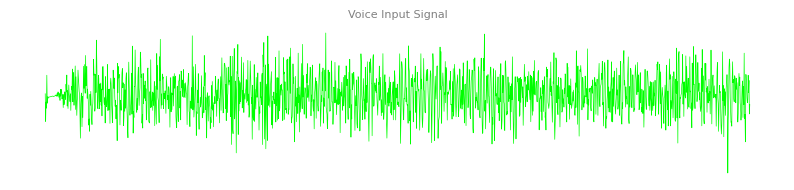

🎤 LISTENING (4s)...


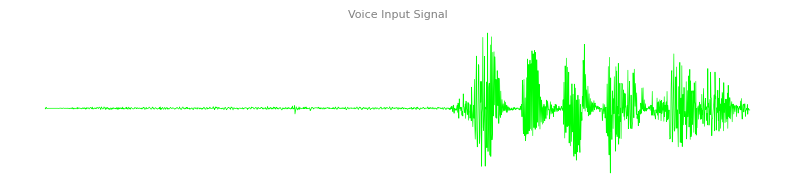

🗣️ You said: What is my current balance?


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

🧠 Intent: check_balance (0.68)
🤖 Bot is thinking...
🎤 LISTENING (4s)...


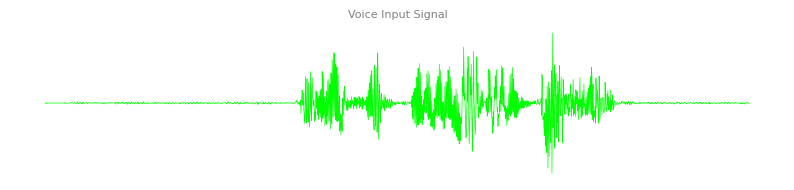

🗣️ You said: Can you book me a room for me?


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

🧠 Intent: book_hotel (0.76)
🤖 Bot is thinking...
🎤 LISTENING (4s)...


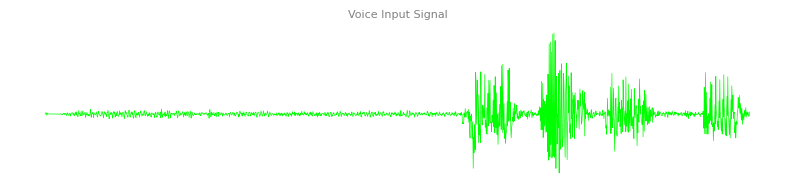

🗣️ You said: Can you please connect me?


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

🧠 Intent: support (0.39)
🤖 Bot is thinking...
🎤 LISTENING (4s)...


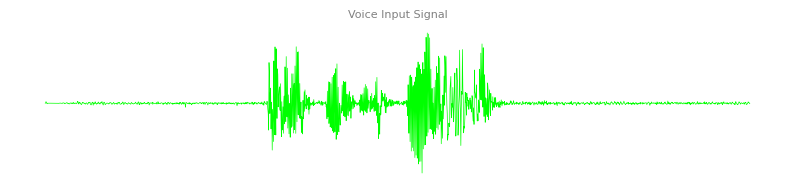

🗣️ You said: Can you please book me a room?


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

🧠 Intent: book_hotel (0.82)
🤖 Bot is thinking...
🎤 LISTENING (4s)...


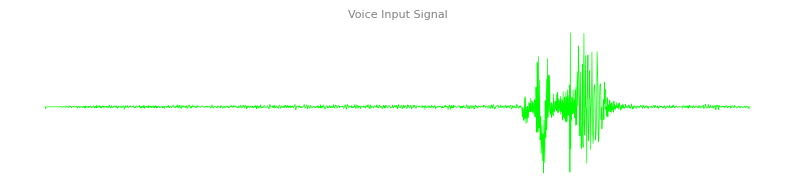

🗣️ You said: Good bye.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

🧠 Intent: goodbye (0.79)
🤖 Bot is thinking...

📊 GENERATING ANALYTICS DASHBOARD...
                       User Query Detected Intent  Latency (sec)
0     What is my current balance?   check_balance          12.14
1  Can you book me a room for me?      book_hotel          13.74
2      Can you please connect me?         support           8.92
3  Can you please book me a room?      book_hotel          13.25
4                       Good bye.         goodbye           8.88


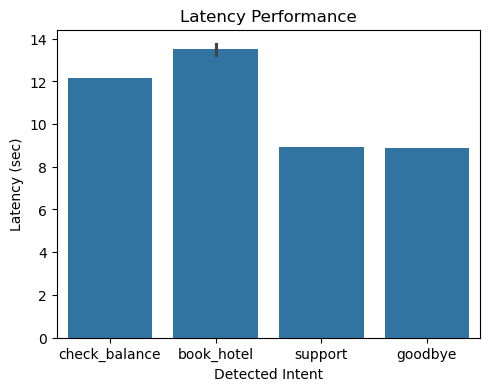

In [6]:
# CELL 5: FINAL INTEGRATION (Fixing Variable Names)

# 1. Ensure all systems are named correctly for the Bot
try:
    # Link the Google Audio System we just created to the name the bot expects
    audio_system = audio 
except NameError:
    # If 'audio' isn't defined, re-initialize the system
    print("⚠️ Re-initializing Audio System...")
    audio_system = AudioSystem()

# 2. Define the Bot Class (Updated to use the new Audio System)
class VoiceBot:
    def __init__(self):
        self.backend = backend_system # Uses the DB from Cell 2
        self.nlu = nlu_engine         # Uses the Transformer NLU from Cell 3
        self.audio = audio_system     # Uses the Google TTS from Cell 4
        self.current_user = "101"     # Simulate logged-in user
        self.interaction_log = []

    def run(self):
        # Greet the user
        user_name = self.backend.get_user_details(self.current_user)[1]
        welcome_msg = f"System online. Welcome back, {user_name}. I am listening."
        self.audio.speak(welcome_msg)
        
        # Give the welcome message a moment to play before recording
        time.sleep(3) 
        
        while True:
            start_time = time.time()
            
            # 1. Input
            try:
                wav_file = self.audio.record(duration=4) # Record for 4 seconds
                user_text = self.audio.transcribe(wav_file)
            except Exception as e:
                print(f"Microphone error: {e}")
                continue
            
            # Skip processing if silence
            if not user_text or len(user_text) < 2:
                continue

            print(f"🗣️ You said: {user_text}")

            # 2. NLU (Understanding)
            intent, confidence = self.nlu.predict_intent(user_text)
            print(f"🧠 Intent: {intent} ({confidence:.2f})")
            
            # 3. Logic & Response
            response = self._generate_response(intent)
            
            # 4. Output (Play Audio)
            self.audio.speak(response)
            
            # 5. Log Metrics
            end_time = time.time()
            self.interaction_log.append({
                "User Query": user_text,
                "Detected Intent": intent,
                "Confidence Score": confidence,
                "Latency (sec)": round(end_time - start_time, 2)
            })
            
            # Wait a moment for audio to finish before loop restarts
            time.sleep(4) 
            
            if intent == "goodbye":
                self._show_analytics_dashboard()
                break

    def _generate_response(self, intent):
        if intent == "check_balance":
            user_data = self.backend.get_user_details(self.current_user)
            return f"Your current balance is ${user_data[2]:,.2f}."
        elif intent == "book_hotel":
            return self.backend.log_transaction(self.current_user, "Luxury Suite Reservation")
        elif intent == "support":
            return "Connecting you to a human agent."
        elif intent == "goodbye":
            return "Shutting down. Goodbye."
        else:
            return "I didn't understand. Ask about balance or booking."

    def _show_analytics_dashboard(self):
        print("\n" + "="*40)
        print("📊 GENERATING ANALYTICS DASHBOARD...")
        print("="*40)
        if not self.interaction_log: return

        df = pd.DataFrame(self.interaction_log)
        print(df[["User Query", "Detected Intent", "Latency (sec)"]])
        
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        sns.barplot(data=df, x="Detected Intent", y="Latency (sec)")
        plt.title("Latency Performance")
        plt.show()

# --- START THE BOT ---
bot = VoiceBot()
try:
    bot.run()
except KeyboardInterrupt:
    print("🛑 Stopped.")